# Preparación de los datos

## Extraccion del archivo tratado

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Telecomx_latam_Jt.csv to Telecomx_latam_Jt.csv


In [2]:
import pandas as pd

In [5]:
df = pd.read_csv("Telecomx_latam_Jt.csv")

In [6]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Cuentas_Diarias,Cantidad_Servicios
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667,4
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667,2
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333,2
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667,5
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667,3


## Eliminación de Columnas Irrelevantes

In [7]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'Cuentas_Diarias', 'Cantidad_Servicios'],
      dtype='object')

In [8]:
df = df.drop(columns=['customerID'])

In [9]:
df.columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Cuentas_Diarias',
       'Cantidad_Servicios'],
      dtype='object')

## Encoding

In [10]:
#Revisar tipos de datos
df.dtypes

,0
Churn,int64
gender,object
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,object
InternetService,object
OnlineSecurity,int64


In [11]:
#Aplicar one-hot encoding a columnas categoricas
df_encoded = pd.get_dummies(df, columns=[
    'gender',
    'MultipleLines',
    'InternetService',
    'Contract',
    'PaymentMethod'
], drop_first=True)

In [12]:
df_encoded.head()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,9,1,0,1,0,1,...,False,False,False,False,False,True,False,False,False,True
1,0,0,0,0,9,1,0,0,0,0,...,True,False,True,False,False,False,False,False,False,True
2,1,0,0,0,4,1,0,0,1,0,...,True,False,False,True,False,False,False,False,True,False
3,1,1,1,0,13,1,0,1,1,0,...,True,False,False,True,False,False,False,False,True,False
4,1,1,1,0,3,1,0,0,0,1,...,False,False,False,True,False,False,False,False,False,True


In [13]:
df_encoded.shape

(7032, 27)

## Verificación de la Proporción de Cancelación (Churn)

In [14]:
#Clientes por clase
df_encoded['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


In [19]:
#La proporcion
df_encoded['Churn'].value_counts(normalize=True)


,proportion
Churn,
0,0.734215
1,0.265785


## Balanceo de Clases

In [21]:
#Instalar SMOTE
!pip install imbalanced-learn

In [22]:
#Importar herramientas de balanceo
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

In [25]:
#Separar variables
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [26]:
#Dividir entremiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
#Oversampling
from imblearn.over_sampling import RandomOverSampler

oversample = RandomOverSampler(random_state=42)

X_res, y_res = oversample.fit_resample(X_train, y_train)

print(y_res.value_counts())

Churn
0    4130
1    4130
Name: count, dtype: int64


## Normalización o Estandarización

Estos algoritmos sí necesitan datos escalados:

KNN (K-Nearest Neighbors) → usa distancia
SVM (Support Vector Machine) → depende de distancias
Regresión Logística
Redes Neuronales

In [28]:
#Estandarizacion con StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

# Correlación y Selección de Variables

## Analisis de correlación

In [29]:
#Calcular la matriz de correlación
corr_matrix = df_encoded.corr()

In [30]:
#Visualizar la matriz con un heatmap
import seaborn as sns
import matplotlib.pyplot as plt

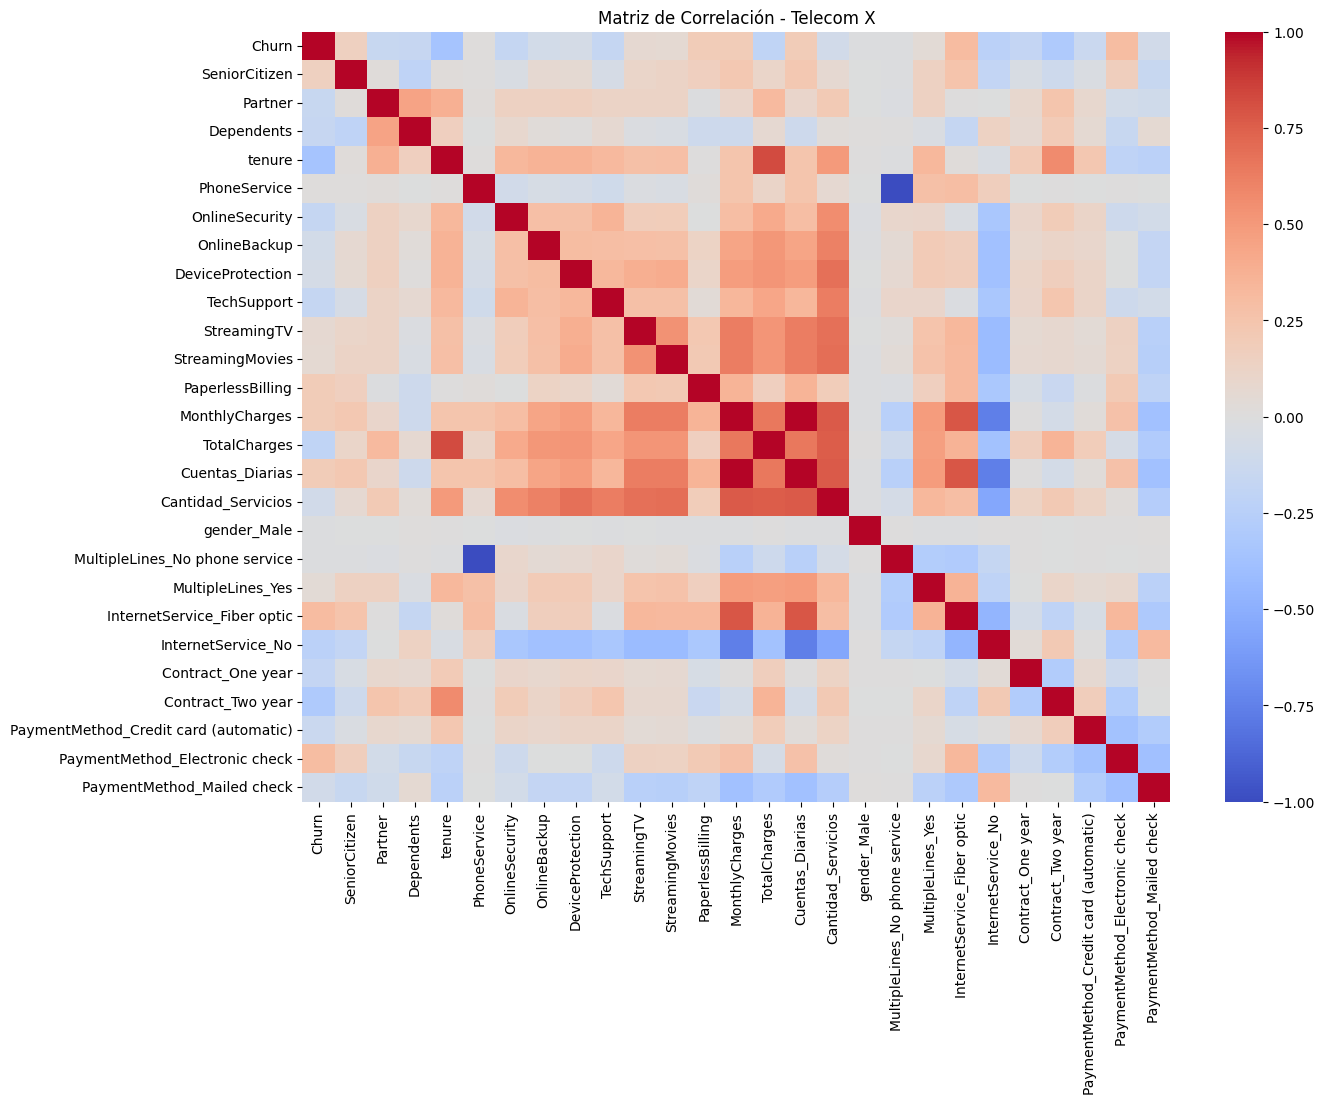

In [31]:
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Matriz de Correlación - Telecom X")
plt.show()

## Analisis dirigido

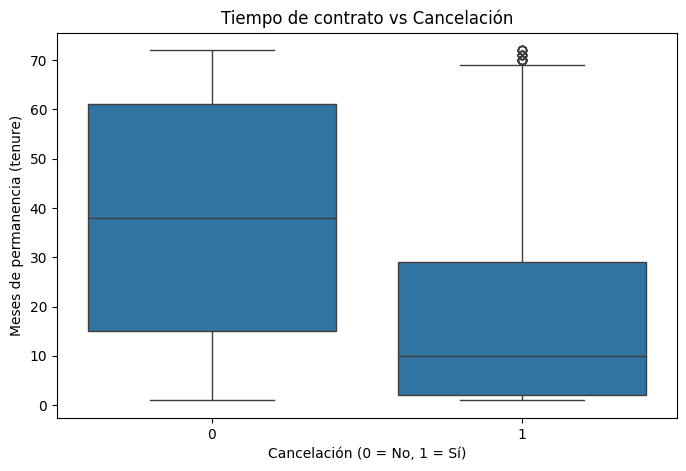

In [32]:
#Tiempo de contrato × Cancelación
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df_encoded)
plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Meses de permanencia (tenure)")
plt.show()

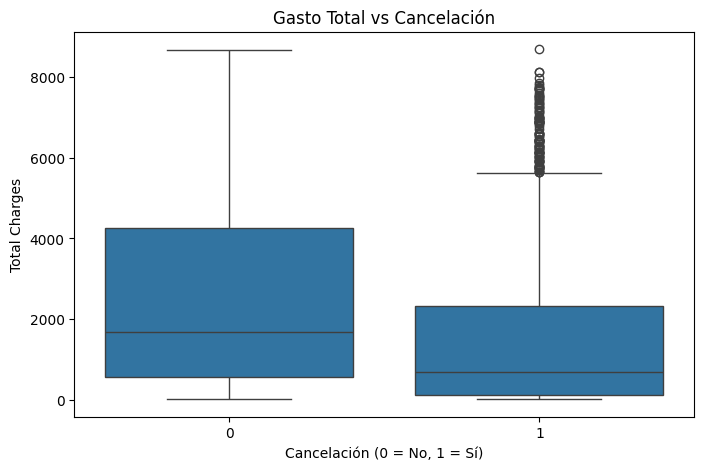

In [33]:
#Gasto total × Cancelación
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='TotalCharges', data=df_encoded)
plt.title("Gasto Total vs Cancelación")
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Total Charges")
plt.show()

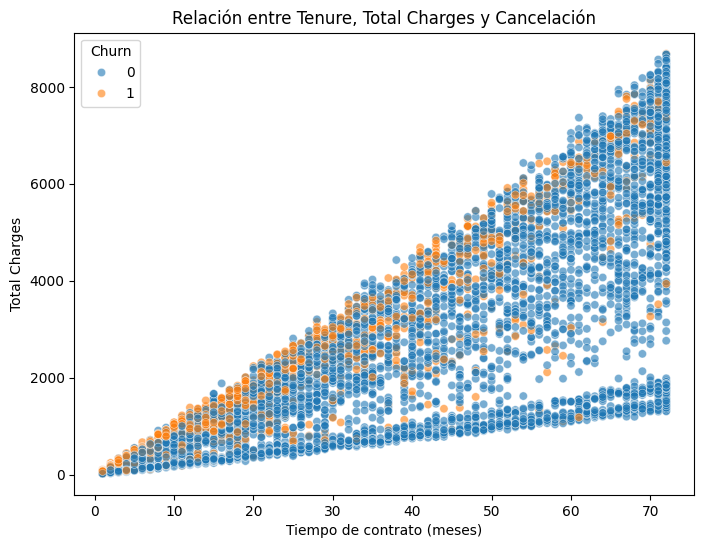

In [34]:
#Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='tenure',
    y='TotalCharges',
    hue='Churn',
    data=df_encoded,
    alpha=0.6
)

plt.title("Relación entre Tenure, Total Charges y Cancelación")
plt.xlabel("Tiempo de contrato (meses)")
plt.ylabel("Total Charges")
plt.show()

# Modelado Predictivo

## Separación de datos

In [35]:
#Separar variables predictorias y variable objetivo
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [36]:
#Dividir los datos
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% prueba
    random_state=42,    # reproducibilidad
    stratify=y          # mantiene proporción de churn
)

In [37]:
#Verificar dimensiones
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 26)
X_test: (1407, 26)
y_train: (5625,)
y_test: (1407,)


## Creación de modelos

In [38]:
#Normalizar los datos
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
#Modelo 1: Regresión logística
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Accuracy Regresión Logística:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy Regresión Logística: 0.8009950248756219
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



In [40]:
#Modelo 2:Random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy Random Forest: 0.7853589196872779
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



In [42]:
#Comparar modelos
print("Accuracy Regresión Logística:", accuracy_score(y_test, y_pred_log))
print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))

Accuracy Regresión Logística: 0.8009950248756219
Accuracy Random Forest: 0.7853589196872779


## Evaluación de los modelos

In [43]:
#Importar métricas necesarias
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
#Metricas para cada modelo
#Regresión logistica
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Regresión Logística")
print("Accuracy:", accuracy_log)
print("Precision:", precision_log)
print("Recall:", recall_log)
print("F1-score:", f1_log)

Regresión Logística
Accuracy: 0.8009950248756219
Precision: 0.6556291390728477
Recall: 0.5294117647058824
F1-score: 0.5857988165680473


In [46]:
#Metricas para cada modelo
#Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)

Random Forest
Accuracy: 0.7853589196872779
Precision: 0.6285714285714286
Recall: 0.47058823529411764
F1-score: 0.5382262996941896


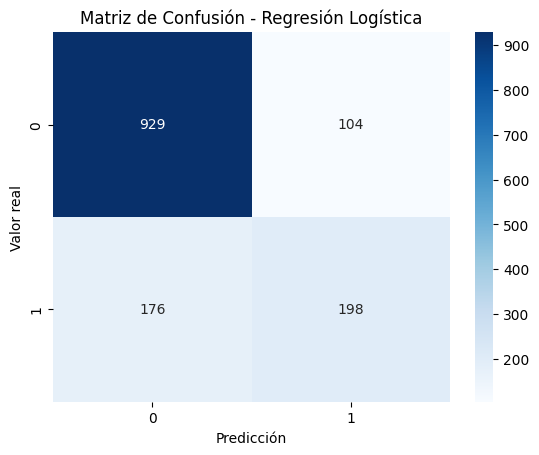

In [48]:
#Matriz de confusión
#Regresión logistica
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure()
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

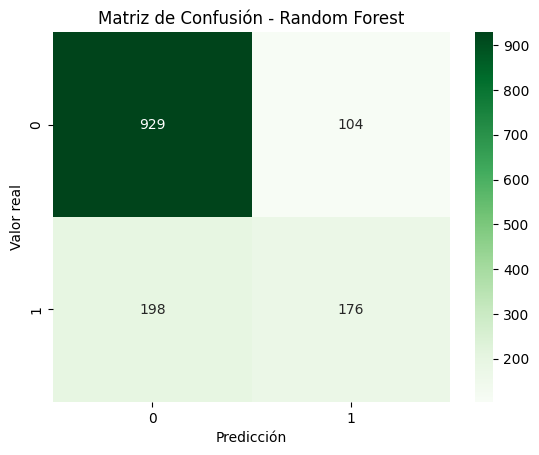

In [49]:
#Matriz de confusión
#Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [50]:
#Comparacion en tabla
import pandas as pd

resultados = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [accuracy_log, accuracy_rf],
    "Precision": [precision_log, precision_rf],
    "Recall": [recall_log, recall_rf],
    "F1-score": [f1_log, f1_rf]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.800995,0.655629,0.529412,0.585799
1,Random Forest,0.785359,0.628571,0.470588,0.538226


# Interpretación y Conclusiones

## Análisis de la Importancia de las Variables

In [51]:
#Importancia de variables en Regresión logistica
import pandas as pd

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": log_model.coef_[0]
})

coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)

coeficientes.head(10)

,Variable,Coeficiente
13,TotalCharges,0.622835
19,InternetService_Fiber optic,0.612595
9,StreamingTV,0.220527
11,PaperlessBilling,0.181265
24,PaymentMethod_Electronic check,0.168574
18,MultipleLines_Yes,0.153077
10,StreamingMovies,0.151410
0,SeniorCitizen,0.093944
7,DeviceProtection,0.033652
15,Cantidad_Servicios,0.026103


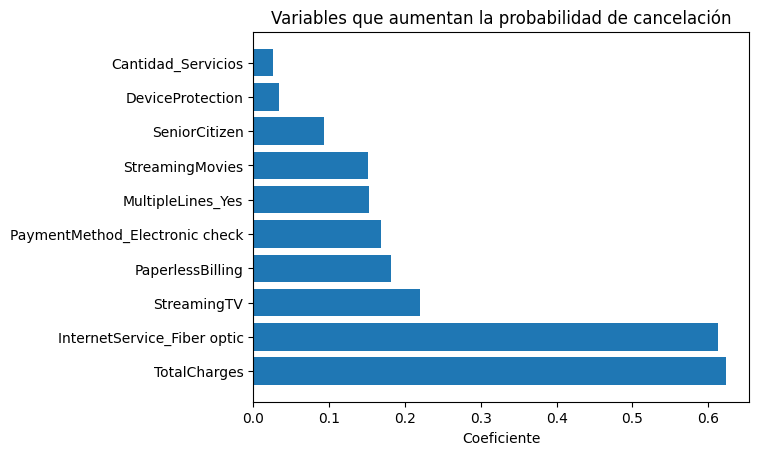

In [52]:
#Coeficiones
import matplotlib.pyplot as plt

coeficientes_top = coeficientes.head(10)

plt.figure()
plt.barh(coeficientes_top["Variable"], coeficientes_top["Coeficiente"])
plt.title("Variables que aumentan la probabilidad de cancelación")
plt.xlabel("Coeficiente")
plt.show()

In [53]:
#Importancia de variables en Random Forest
importances = rf_model.feature_importances_

rf_importance = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": importances
})

rf_importance = rf_importance.sort_values(by="Importancia", ascending=False)

rf_importance.head(10)

,Variable,Importancia
13,TotalCharges,0.165263
3,tenure,0.147442
12,MonthlyCharges,0.133107
14,Cuentas_Diarias,0.130980
24,PaymentMethod_Electronic check,0.043375
19,InternetService_Fiber optic,0.040519
15,Cantidad_Servicios,0.032228
22,Contract_Two year,0.030434
16,gender_Male,0.025341
11,PaperlessBilling,0.023670


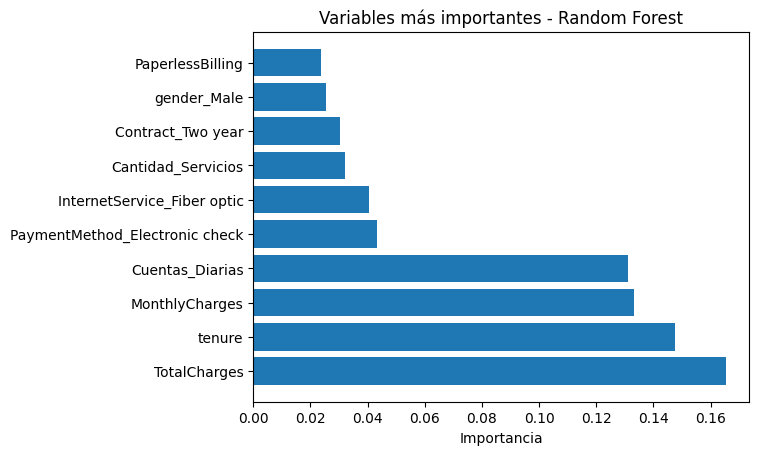

In [54]:
#Variables
top_rf = rf_importance.head(10)

plt.figure()
plt.barh(top_rf["Variable"], top_rf["Importancia"])
plt.title("Variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.show()


## Conclusión

**Predicción de Cancelación de Clientes (Churn)**

Tras el análisis exploratorio y el entrenamiento de modelos predictivos (Regresión Logística y Random Forest), se identificaron los factores más influyentes en la cancelación de clientes en Telecom X.

Los resultados muestran que variables como el tipo de contrato, la antigüedad del cliente (tenure), los cargos mensuales y el método de pago tienen una fuerte relación con el churn. En particular, los clientes con contratos mes a mes, baja antigüedad y cargos mensuales más altos presentan una mayor probabilidad de cancelar el servicio. Por el contrario, los clientes con contratos a largo plazo y mayor permanencia en la empresa muestran una menor tendencia a cancelar.

En la comparación de modelos, Random Forest presentó el mejor desempeño general, debido a su capacidad para capturar relaciones complejas entre variables. La Regresión Logística también ofreció resultados interpretables, permitiendo identificar el impacto individual de cada variable.

Estrategias de retención propuestas

*    Incentivar contratos de largo plazo mediante descuentos o beneficios.
*    Fortalecer la retención de clientes nuevos, especialmente durante los primeros meses.
*    Revisar la estructura de precios para clientes con cargos mensuales altos.
*    Implementar programas de fidelización y soporte proactivo para clientes con mayor riesgo de cancelación.

En conclusión, el uso de modelos predictivos permite identificar clientes con alta probabilidad de churn y diseñar estrategias de retención más efectivas, contribuyendo a mejorar la estabilidad y rentabilidad de Telecom X.